### Visualizing DNA Protection Patterns through V-Plot Construction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

fragment_counts = defaultdict(int)
# For getting mapped.bed file, use: python unzip_bed_files.py in the Programming-Assignment directory
with open("mapped.bed", "r") as bed_file:
    for data_line in bed_file:
        fields = data_line.strip().split()

        midpoint1 = (int(fields[2]) + int(fields[3])) / 2
        midpoint2 = (int(fields[8]) + int(fields[9])) / 2

        rel_position = midpoint2 - midpoint1
        frag_length = int(fields[9]) - int(fields[8])

        fragment_counts[(rel_position, frag_length)] += 1

position_values = sorted(set(coord[0] for coord in fragment_counts))
length_values = sorted(set(coord[1] for coord in fragment_counts))
position_to_index = {pos: idx for idx, pos in enumerate(position_values)}
length_to_index = {length: idx for idx, length in enumerate(length_values)}

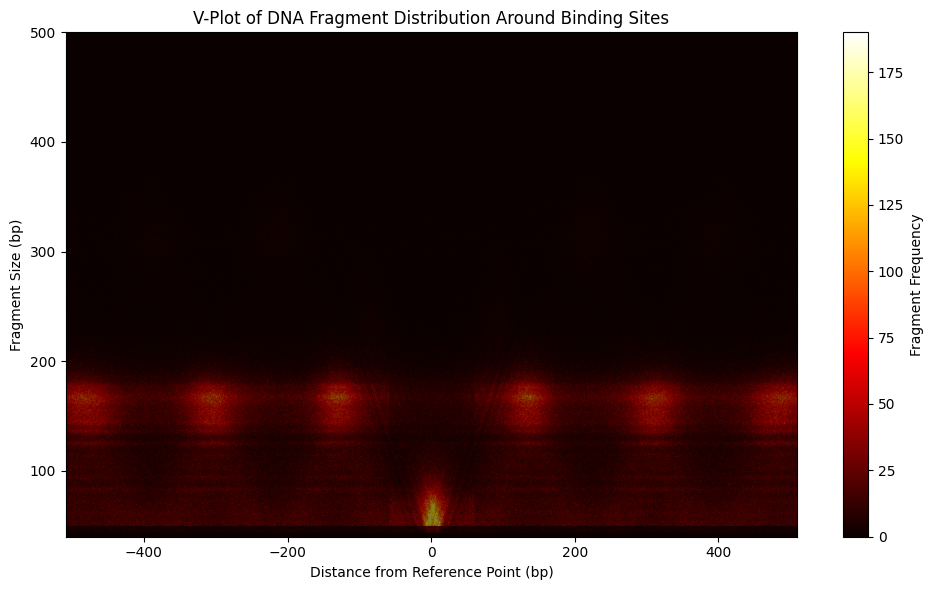

In [4]:
# Generate density visualization of fragment distribution
density_matrix = np.zeros((len(length_values), len(position_values)))

for (pos, length), count in fragment_counts.items():
    density_matrix[length_to_index[length]][position_to_index[pos]] = count

plt.figure(figsize=(10, 6))
plt.imshow(
    density_matrix,
    aspect='auto',
    origin='lower',
    extent=[min(position_values), max(position_values), min(length_values), max(length_values)],
    cmap="hot"
)
plt.colorbar(label="Fragment Frequency")
plt.xlabel("Distance from Reference Point (bp)")
plt.ylabel("Fragment Size (bp)")
plt.title("V-Plot of DNA Fragment Distribution Around Binding Sites")
plt.tight_layout()
plt.show()
